# Классификация временных рядов

Классической задачей в анализе временных рядов является классификация. Существует огромное количество алгоритмов, подходящих для этой задачи, многие из которых не относятся к тяжёлому глубокому обучению.

В этом блокноте мы представим базовый код для предобработки данных и оценки результата.

В качестве модели будет использоваться k-NN — алгоритм ближайших соседей. Это вычислительно тяжелый, неоптимальный алгоритм. Замените его в своих решениях на что-нибудь посимпатичнее =)

## Особенности алгоритмов

Вы можете использовать стандартные алгоритмы для анализа табличных данных, однако специализированные алгоритмы для классификации временных рядов, как правило, отрабатывают лучше.

Распространенное, но ошибочное решение классификации временных рядов состоит в том, чтобы рассматривать каждый момент времени как отдельный признак и напрямую применять стандартный алгоритм обучения (например, классификаторы scikit-learn). При таком подходе алгоритм игнорирует информацию, содержащуюся во временном порядке данных. Если бы порядок во временном ряду был бы изменен, прогнозы не изменились бы.

## Основные концепции

Многие алгоритмы, специфичные для временных рядов, представляют собой комбинацию преобразованных временных рядов и традиционных алгоритмов классификации, например, из scikit-learn.

Итак, для моделей **нужны признаки**. И извлекать их можно различными способами.

Признаки можно извлекать **глобально** (по всему временному ряду) или **локально** (по регулярным или случайным интервалам, скользящим окнам и т.д.).

Ряды можно преобразовать в **наборы статистик** (среднее значение, стандартное отклонение, тренд) или в другие ряды (например, преобразование Фурье, ряды подобранных коэффициентов авторегрессии).

Наконец, преобразования могут быть одномерными или многомерными.



# k-NN с DTW

Классический алгоритм ближайших соседей использует Евклидово расстояние. Для временных рядов такая мера расстояния не подходит, потому что игнорирует временную зависимость. Если один и тот же ряд сместить на 1 временной отсчёт, то Евклидово расстояние может быть огромным.

Поэтому мы должны заменить меру расстояния на что-то более адекватное. **DTW (Dynamic Time Wrapping)** является одним из способов сравнения временных рядов независимо от размеров временных интервалов или длин ряда.

**DWT — корень из суммы квадратов расстояний между каждой точкой в $X$ и *ближайшей точкой* в $Y$**.

По ссылке вы можете найти подробный [гайд ✏️[blog]](https://rtavenar.github.io/blog/dtw.html) с гифками и формулами.

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/YandexDS/Locomotion_journey/euclidean_vs_dtw.jpg" width="900"></center>

<center><em>Source: <a href="https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B4%D0%B8%D0%BD%D0%B0%D0%BC%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9_%D1%82%D1%80%D0%B0%D0%BD%D1%81%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%B8_%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D0%BE%D0%B9_%D1%88%D0%BA%D0%B0%D0%BB%D1%8B">Алгоритм динамической трансформации временной шкалы</a></em></center>

Вот так это выглядит в коде.

In [ ]:
!pip install -q dtaidistance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.8 MB/s eta 0:00:00


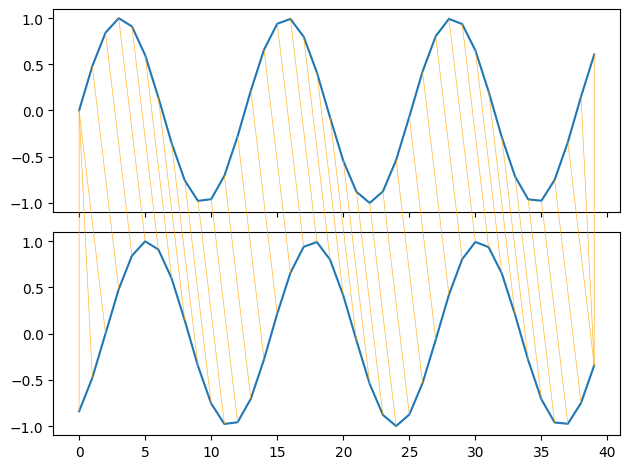

In [ ]:
import numpy as np
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

x = np.arange(0, 20, .5)
s1 = np.sin(x)
s2 = np.sin(x - 1)
path = dtw.warping_path(s1, s2)
dtwvis.plot_warping(s1, s2, path)
distance = dtw.distance(s1, s2)

Импортируем библиотеки, подключаем свой Google Диск, куда мы положили данные.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/kaggledata/train.csv")

<ipython-input-5-2d786a86cfc7>:1: DtypeWarning: Columns (19,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/content/drive/MyDrive/kaggledata/train.csv")


Заменяем названия классов на числовые метки.

In [ ]:
train["PathologyGroup"] = train["PathologyGroup"].map({"Healthy": 0, "Orthopedic": 1, "Neurological": 2})

In [ ]:
train.head(3)

,exp_num,time_idx,LAV,LAX,LAY,LAZ,LRV,LRX,LRY,LRZ,...,Age,Gender,Height,Weight,BMI,Laterality,Sensor,WalkedDistance,WalkingSpeed,PathologyGroup
0,0,0,-0.005220,-0.002718,-0.0022,-0.004271,0.204464,0.3,0.0,0.0,...,70,F,1.65,72,26.4,Right,TCon,10.0,1.3,2
1,0,1,0.000939,-0.001918,0.0011,0.002829,0.360901,0.5,1.0,-0.2,...,70,F,1.65,72,26.4,Right,TCon,10.0,1.3,2
2,0,2,-0.000438,-0.001518,-0.0011,0.001029,0.576958,0.5,-0.3,0.4,...,70,F,1.65,72,26.4,Right,TCon,10.0,1.3,2


Итак, какие у нас есть колонки признаков?

In [ ]:
train.columns

Index(['exp_num', 'time_idx', 'LAV', 'LAX', 'LAY', 'LAZ', 'LRV', 'LRX', 'LRY',
       'LRZ', 'RAV', 'RAX', 'RAY', 'RAZ', 'RRV', 'RRX', 'RRY', 'RRZ',
       'Subject', 'Age', 'Gender', 'Height', 'Weight', 'BMI', 'Laterality',
       'Sensor', 'WalkedDistance', 'WalkingSpeed', 'PathologyGroup'],
      dtype='object')

Оставим только временные ряды. Остальные признаки могут быть использованы вами в дальнейшем.

In [ ]:
train.columns[:18]

Index(['exp_num', 'time_idx', 'LAV', 'LAX', 'LAY', 'LAZ', 'LRV', 'LRX', 'LRY',
       'LRZ', 'RAV', 'RAX', 'RAY', 'RAZ', 'RRV', 'RRX', 'RRY', 'RRZ'],
      dtype='object')

Не забудем номера классов!

In [ ]:
joined_list = [*train.columns[:18], train.columns[-1]]

In [ ]:
joined_list

['exp_num',
 'time_idx',
 'LAV',
 'LAX',
 'LAY',
 'LAZ',
 'LRV',
 'LRX',
 'LRY',
 'LRZ',
 'RAV',
 'RAX',
 'RAY',
 'RAZ',
 'RRV',
 'RRX',
 'RRY',
 'RRZ',
 'PathologyGroup']

In [ ]:
train_ts = train[joined_list]

Сделаем словарик из датафреймов по номеру эксперимента.

In [ ]:
dfs = dict(tuple(train_ts.groupby("exp_num")))

Подготовим данные для обучения k-NN. Из-за того, что k-NN требует множество вычислений (а также потому, что для классификации вовсе не обязателен каждый временной отсчёт), возьмём каждую сотую точку.

И сохраним метки.

In [ ]:
labels = []
for key, value in dfs.items():
  labels.append(value["PathologyGroup"].unique())
  dfs[key] = value.drop(columns=["exp_num", "time_idx", "PathologyGroup"]).iloc[::100].to_numpy()

Вот такие размеры у первой таблички в итоге получились.

In [ ]:
dfs[0].shape

(41, 16)

Для разделения на обучение, валидацию и тест переведём данные в подходящий формат.

In [ ]:
data = list(dfs.values())

In [ ]:
len(data)

1020

Сделаем из меток вектор (до этого у нас была лишняя размерность).

In [ ]:
labels = np.array(labels).ravel()
print(labels.shape)

(1020,)


Разделим данные. Для демонстрации возьмём лишь часть данных из обучающей выборки (`train_size = 0.2, test_size = 0.05)`.

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split (data, labels, train_size = 0.2, test_size = 0.05, stratify = labels, random_state = 42)

А теперь немножко магии временных рядов. Если бы у нас все данные были одного размера, проблем было меньше. Чтобы не обучать по одному объекту за раз, воспользуемся библиотекой `tslearn`, которая позволяет автоматически подготовить наши данные для обучения модели. По факту это padding значениями `nan`.

In [ ]:
!pip install -q tslearn

In [ ]:
from tslearn.utils import to_time_series_dataset
x_train = to_time_series_dataset(x_train)
x_val = to_time_series_dataset(x_val)

In [ ]:
x_train.shape

(204, 126, 16)

Зададим модель k-NN. Воспользуемся моделью, оптимизированной для временных рядов. В ней мы укажем, что будем считать расстояния по метрике DTW, а количество соседей — 2 (для демонстрации).

In [ ]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=2, metric="dtw", n_jobs = -1)

Обучим модель.

In [ ]:
knn_dtw.fit(x_train, y_train)

KNeighborsTimeSeriesClassifier(n_jobs=-1, n_neighbors=2)

Посморим на качество предсказаний на обучении и на валидации. Несмотря на то, что мы взяли относительно немного данных, это займёт время. Если вы воспользуетесь более современными алгоритмами, то, скорее всего, существенно ускоритесь.

In [ ]:
train_preds = knn_dtw.predict (x_train)

In [ ]:
from sklearn.metrics import classification_report
target_names = ["Healthy", "Orthopedic", "Neurological"]

print(classification_report(y_train, train_preds, target_names=target_names))

              precision    recall  f1-score   support

     Healthy       0.65      1.00      0.79        48
  Orthopedic       0.40      0.73      0.52        49
Neurological       1.00      0.38      0.55       107

    accuracy                           0.61       204
   macro avg       0.68      0.71      0.62       204
weighted avg       0.77      0.61      0.60       204



In [ ]:
val_preds = knn_dtw.predict (x_val)

In [ ]:
print(classification_report(y_val, val_preds, target_names=target_names))

              precision    recall  f1-score   support

     Healthy       0.27      0.50      0.35        12
  Orthopedic       0.23      0.50      0.32        12
Neurological       1.00      0.11      0.20        27

    accuracy                           0.29        51
   macro avg       0.50      0.37      0.29        51
weighted avg       0.65      0.29      0.26        51



Теперь всё то же самое сделаем с тестовыми данными, получим ответ и сохраним его в нужном виде.

In [ ]:
test = pd.read_csv("/content/drive/MyDrive/kaggledata/test.csv")

In [ ]:
test.columns

Index(['exp_num', 'time_idx', 'LAV', 'LAX', 'LAY', 'LAZ', 'LRV', 'LRX', 'LRY',
       'LRZ', 'RAV', 'RAX', 'RAY', 'RAZ', 'RRV', 'RRX', 'RRY', 'RRZ', 'Age',
       'Gender', 'Height', 'Weight', 'BMI', 'Laterality', 'Sensor',
       'WalkedDistance', 'WalkingSpeed'],
      dtype='object')

In [ ]:
test_ts = test[test.columns[:18]]

In [ ]:
dfs_test = dict(tuple(test_ts.groupby("exp_num")))

In [ ]:
for key, value in dfs_test.items():
  dfs_test[key] = value.drop(columns=["exp_num", "time_idx"]).iloc[::100].to_numpy()

In [ ]:
data_test = list(dfs_test.values())

In [ ]:
X_test = to_time_series_dataset(data_test)

In [ ]:
test_preds = knn_dtw.predict (X_test)

In [ ]:
print(test_preds)

[1 1 1 1 2 0 0 1 1 1 2 1 1 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 1 2 1 0 0 1 1 1 0
 1 1 1 1 1 2 1 1 1 1 0 0 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0
 1 1 0 0 2 0]


In [ ]:
answer = list(zip(list(dfs_test.keys()),test_preds))

In [ ]:
answer

[(0, 1),
 (1, 1),
 (2, 1),
 (3, 1),
 (4, 2),
 (5, 0),
 (6, 0),
 (7, 1),
 (8, 1),
 (9, 1),
 (10, 2),
 (11, 1),
 (12, 1),
 (13, 0),
 (14, 0),
 (15, 1),
 (16, 1),
 (17, 1),
 (18, 1),
 (19, 1),
 (20, 1),
 (21, 0),
 (22, 0),
 (23, 0),
 (24, 0),
 (25, 1),
 (26, 1),
 (27, 1),
 (28, 1),
 (29, 2),
 (30, 1),
 (31, 0),
 (32, 0),
 (33, 1),
 (34, 1),
 (35, 1),
 (36, 0),
 (37, 1),
 (38, 1),
 (39, 1),
 (40, 1),
 (41, 1),
 (42, 2),
 (43, 1),
 (44, 1),
 (45, 1),
 (46, 1),
 (47, 0),
 (48, 0),
 (49, 0),
 (50, 1),
 (51, 1),
 (52, 1),
 (53, 0),
 (54, 0),
 (55, 0),
 (56, 0),
 (57, 0),
 (58, 1),
 (59, 1),
 (60, 1),
 (61, 1),
 (62, 1),
 (63, 1),
 (64, 0),
 (65, 0),
 (66, 1),
 (67, 1),
 (68, 1),
 (69, 1),
 (70, 0),
 (71, 1),
 (72, 1),
 (73, 0),
 (74, 1),
 (75, 1),
 (76, 0),
 (77, 0),
 (78, 2),
 (79, 0)]

In [ ]:
test_preds_df = pd.DataFrame(answer, columns=["exp_num","PathologyGroup"])

In [ ]:
test_preds_df.to_csv("/content/drive/MyDrive/kaggledata/preds.csv", index=False)